# Report of cleaning raw data:

# Introduction:

In [1]:
import pandas as pd
file_path1="modified.csv"
df=pd.read_csv(file_path1)
print(df)

    sepal length (cm) sepal width (cm) petal length (cm) petal width (cm)  \
0                 5.1        wrong_3.5               1.4              0.2   
1                 4.9                3               1.4              0.2   
2                 4.7              3.2               1.3              NaN   
3                 4.6              3.1               1.5              0.2   
4                   5              3.6               1.4              0.2   
..                ...              ...               ...              ...   
145               6.7                3               5.2              2.3   
146               NaN              2.5                 5              1.9   
147               6.5              NaN               5.2                2   
148               6.2              3.4               5.4              2.3   
149               5.9                3               5.1              1.8   

             target  
0       Iris-setosa  
1       Iris-setosa  
2        

**Checking null values:**

In [2]:
print(df.isnull().sum())

sepal length (cm)    10
sepal width (cm)     13
petal length (cm)    21
petal width (cm)     16
target               15
dtype: int64


**Statitical Summary of Data(Before finding errors):**

In [3]:
print(df.describe())

       sepal length (cm) sepal width (cm) petal length (cm) petal width (cm)  \
count                140              137               129              134   
unique                39               26                48               26   
top                    5                3               1.4              0.2   
freq                   9               21                12               23   

                 target  
count               135  
unique                3  
top     Iris-versicolor  
freq                 46  


**Information of data(Before findng errors):**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sepal length (cm)  140 non-null    object
 1   sepal width (cm)   137 non-null    object
 2   petal length (cm)  129 non-null    object
 3   petal width (cm)   134 non-null    object
 4   target             135 non-null    object
dtypes: object(5)
memory usage: 6.0+ KB


**Shape of Data:**

In [5]:
print("Shape of data(rows,columns):")
print(df.shape)
print("Column names:")
print(df.columns)

Shape of data(rows,columns):
(150, 5)
Column names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


***Handling missing values:***

**Filling out missing values in target column:**

In [6]:
df["target"]=df["target"].fillna(df["target"].mode()[0])
print(df.head(25))

   sepal length (cm) sepal width (cm) petal length (cm) petal width (cm)  \
0                5.1        wrong_3.5               1.4              0.2   
1                4.9                3               1.4              0.2   
2                4.7              3.2               1.3              NaN   
3                4.6              3.1               1.5              0.2   
4                  5              3.6               1.4              0.2   
5                5.4              3.9               1.7              0.4   
6                4.6              3.4               1.4              0.3   
7                NaN              3.4               1.5              0.2   
8                4.4              2.9               1.4              0.2   
9                4.9              3.1               1.5              0.1   
10               5.4              3.7         wrong_1.5              NaN   
11               4.8              3.4               1.6              0.2   
12          

**Correction in the values of column:**

In [7]:
df["sepal length (cm)"]=pd.to_numeric(df["sepal length (cm)"],errors='coerce')
df["sepal width (cm)"]=pd.to_numeric(df["sepal width (cm)"],errors='coerce')
df["petal length (cm)"]=pd.to_numeric(df["petal length (cm)"],errors='coerce')
df["petal width (cm)"]=pd.to_numeric(df["petal width (cm)"],errors='coerce')
print(df.head(25))

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                 5.1               NaN                1.4               0.2   
1                 4.9               3.0                1.4               0.2   
2                 4.7               3.2                1.3               NaN   
3                 4.6               3.1                1.5               0.2   
4                 5.0               3.6                1.4               0.2   
5                 5.4               3.9                1.7               0.4   
6                 4.6               3.4                1.4               0.3   
7                 NaN               3.4                1.5               0.2   
8                 4.4               2.9                1.4               0.2   
9                 4.9               3.1                1.5               0.1   
10                5.4               3.7                NaN               NaN   
11                4.8               3.4 

**Finding mean by Target:**

In [8]:
#mean of sepal length (cm)
print(df.groupby("target")["sepal length (cm)"].mean())

target
Iris-setosa        5.020930
Iris-versicolor    5.864815
Iris-virginica     6.656410
Name: sepal length (cm), dtype: float64


In [9]:
#mean of sepal width (cm)
print(df.groupby("target")["sepal width (cm)"].mean())

target
Iris-setosa        3.418421
Iris-versicolor    2.845614
Iris-virginica     3.016216
Name: sepal width (cm), dtype: float64


In [10]:
#mean of petal width (cm)
print(df.groupby("target")["petal length (cm)"].mean())

target
Iris-setosa        1.466667
Iris-versicolor    4.150943
Iris-virginica     5.611429
Name: petal length (cm), dtype: float64


In [11]:
#mean of petal width (cm)
print(df.groupby("target")["petal width (cm)"].mean())

target
Iris-setosa        0.241026
Iris-versicolor    1.320408
Iris-virginica     2.063415
Name: petal width (cm), dtype: float64


**Filling out missing values:**

In [12]:
df["sepal length (cm)"]=df.groupby("target")["sepal length (cm)"].transform(lambda x: x.fillna(x.mean()))
df["sepal width (cm)"]=df.groupby("target")["sepal width (cm)"].transform(lambda x: x.fillna(x.mean()))
df["petal length (cm)"]=df.groupby("target")["petal length (cm)"].transform(lambda x: x.fillna(x.mean()))
df["petal width (cm)"]=df.groupby("target")["petal width (cm)"].transform(lambda x: x.fillna(x.mean()))
print(df.head(25))

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0             5.10000          3.418421           1.400000          0.200000   
1             4.90000          3.000000           1.400000          0.200000   
2             4.70000          3.200000           1.300000          1.320408   
3             4.60000          3.100000           1.500000          0.200000   
4             5.00000          3.600000           1.400000          0.200000   
5             5.40000          3.900000           1.700000          0.400000   
6             4.60000          3.400000           1.400000          0.300000   
7             5.02093          3.400000           1.500000          0.200000   
8             4.40000          2.900000           1.400000          0.200000   
9             4.90000          3.100000           1.500000          0.100000   
10            5.40000          3.700000           1.466667          0.241026   
11            4.80000          3.400000 

**Information of data(After removing errors):**

In [13]:
print(df.info())        # structure of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


**statistical summary of data(After removing errors):**

In [14]:
print(df.describe())    # statistical summary

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843851          3.067499           3.774069   
std             0.810096          0.411164           1.756476   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.500000   
50%             5.832407          3.008108           4.200000   
75%             6.400000          3.375000           5.200000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.214542  
std            0.749436  
min            0.100000  
25%            0.300000  
50%            1.320408  
75%            1.800000  
max            2.500000  


**Finding null values after correction:**

In [15]:
print(df.isna().sum()) 

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


**Histogram (Distribution of Features):**

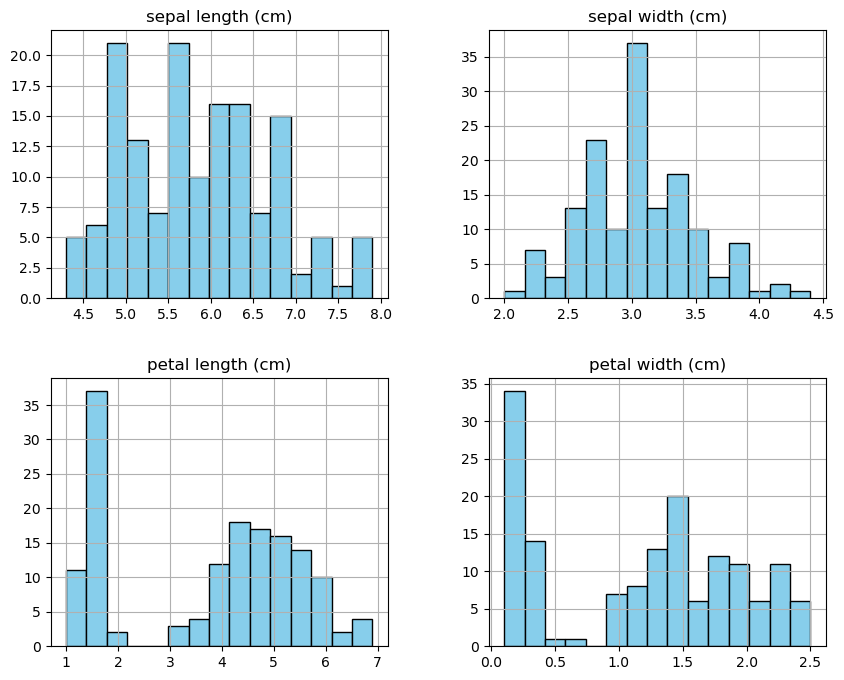

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
data = iris.data
columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Create DataFrame
df = pd.DataFrame(data, columns=columns)

# Create histogram for numeric data
df.hist(figsize=(10,8), bins=15, color='skyblue', edgecolor='black')

# Show plot
plt.show()

**Histogram (Distribution of Features):**

**Bar chart:**

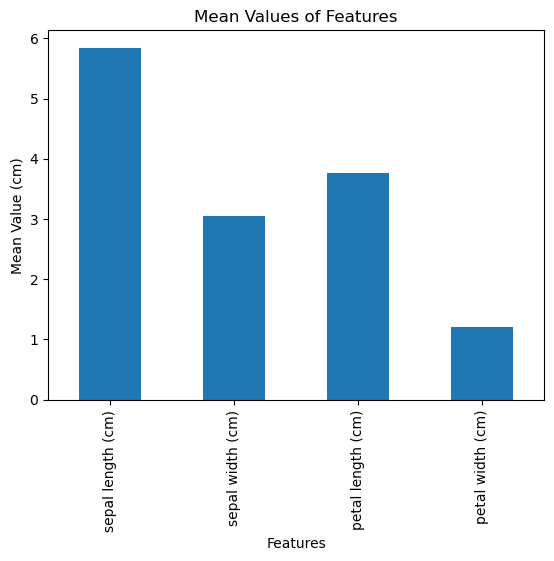

In [17]:
df.mean().plot(kind="bar")
plt.xlabel("Features")
plt.ylabel("Mean Value (cm)")
plt.title("Mean Values of Features")
plt.show()

**Box Plot (Detect Spread & Outliers):**

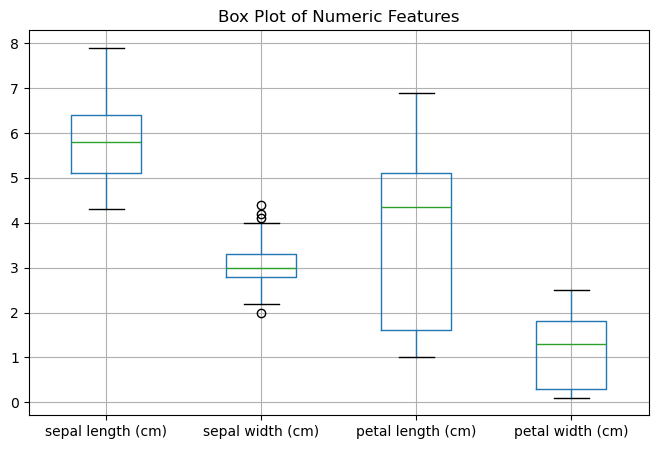

In [18]:
df.boxplot(figsize=(8,5))
plt.title("Box Plot of Numeric Features")
plt.show()

**Scatter Plot (Relationship Between Features):**

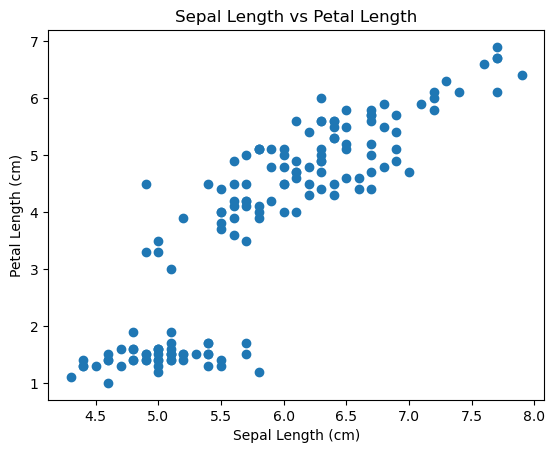

In [19]:
plt.scatter(df["sepal length (cm)"], df["petal length (cm)"])
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Sepal Length vs Petal Length")
plt.show()

**Correlation Heatmap (Optional but High Marks):**

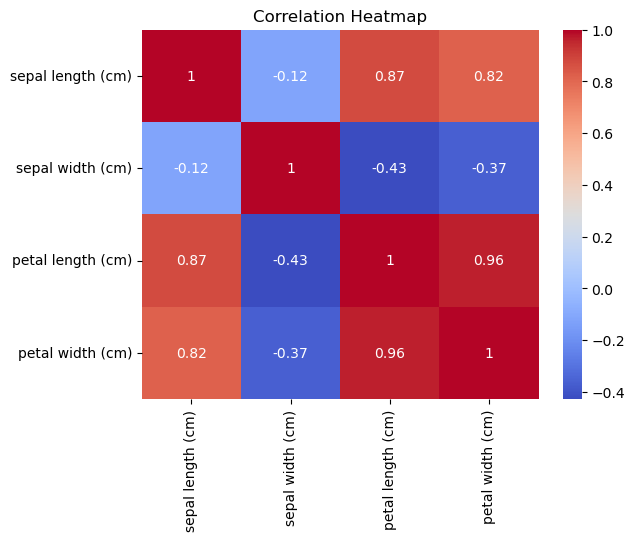

In [20]:
import seaborn as sns

corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()